In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv('Customer Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#replacing the blanks with 0 as tenure is 0 and no total charges are recorded

In [3]:
df["TotalCharges"] = df['TotalCharges'].replace(' ','0')
df["TotalCharges"] = df["TotalCharges"].astype('float')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.isnull().sum().sum()

0

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
df['customerID'].duplicated().sum()

0

In [8]:
def conv(value):
    if value == 1:
        return"Yes"
    else:
        return"no"

df['SeniorCitizen'] = df['SeniorCitizen'].apply(conv)

#Converted 0 and 1 value of SeniorCitizen to Yes/No to make it easier to understand

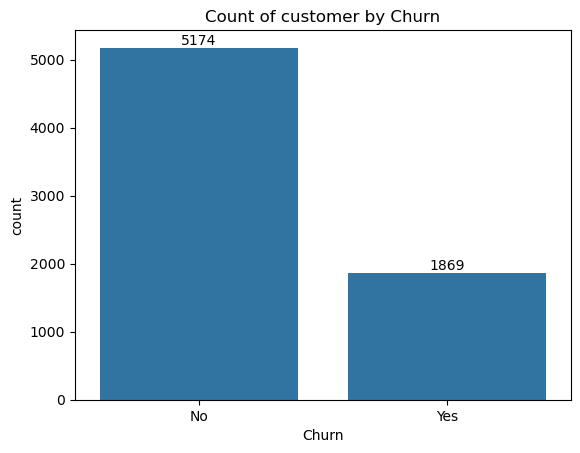

In [9]:
ax = sns.countplot(x = 'Churn', data = df)

ax.bar_label(ax.containers[0])
plt.title('Count of customer by Churn')
plt.show()

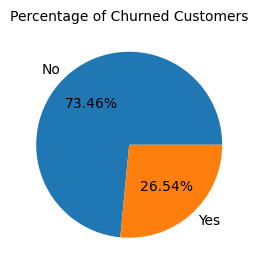

In [10]:
plt. figure(figsize = (3,4)) 
gb= df.groupby('Churn').agg({'Churn':'count'})
plt.pie(gb['Churn'], labels = gb. index, autopct= '%1.2f%%')
plt.title('Percentage of Churned Customers', fontsize= 10)
plt.show()

#from the given piechart we can conclude that 26.54% of our customer have churned out.
#now Let's explore the reason behind it

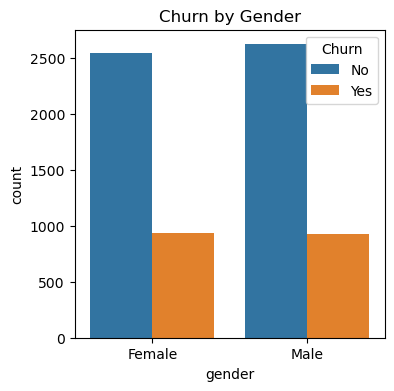

In [11]:
plt.figure(figsize = (4,4))
sns.countplot(x ='gender', data = df, hue = 'Churn')
plt.title('Churn by Gender')
plt.show()

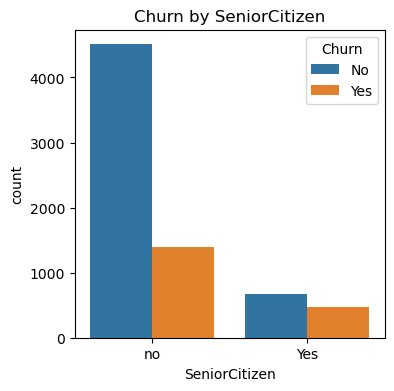

In [12]:
plt.figure(figsize = (4,4))
sns.countplot(x ='SeniorCitizen', data = df, hue = 'Churn')
plt.title('Churn by SeniorCitizen')
plt.show()

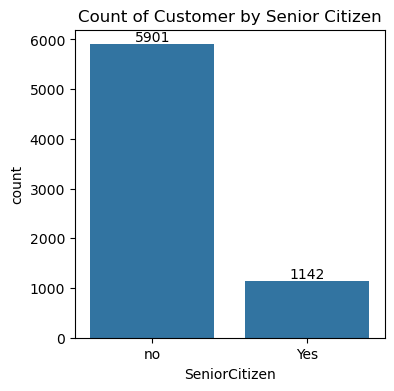

In [18]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x ='SeniorCitizen', data = df)
ax.bar_label(ax.containers[0])
plt.title('Count of Customer by Senior Citizen')
plt.show()

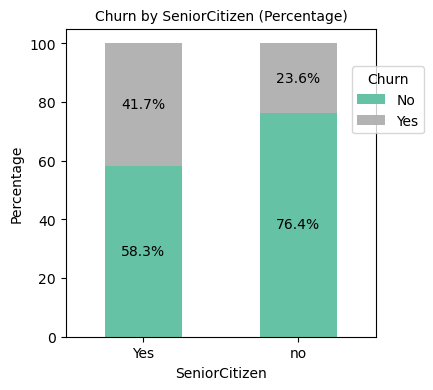

In [21]:
# 1. Create a crosstab of counts
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'])

# 2. Convert to percentage of total within each SeniorCitizen group
ct_percent = ct.div(ct.sum(axis=1), axis=0) * 100

# 3. Plot stacked bar chart
ct_percent.plot(kind='bar', stacked=True, figsize=(4, 4), colormap='Set2')

# 4. Add percentage labels
for i, (index, row) in enumerate(ct_percent.iterrows()):
    cumulative = 0
    for j, (churn_status, value) in enumerate(row.items()):
        plt.text(i, cumulative + value / 2, f'{value:.1f}%', ha='center', va='center', fontsize=10)
        cumulative += value

# 5. Labels and title
plt.title('Churn by SeniorCitizen (Percentage)', fontsize=10)
plt.xlabel('SeniorCitizen')
plt.ylabel('Percentage')
plt.legend(title='Churn', bbox_to_anchor = (0.9,0.9))
plt.xticks( rotation=0)
plt.show()

#Comparatice a greated percentage of people in senior citizen category have churned 

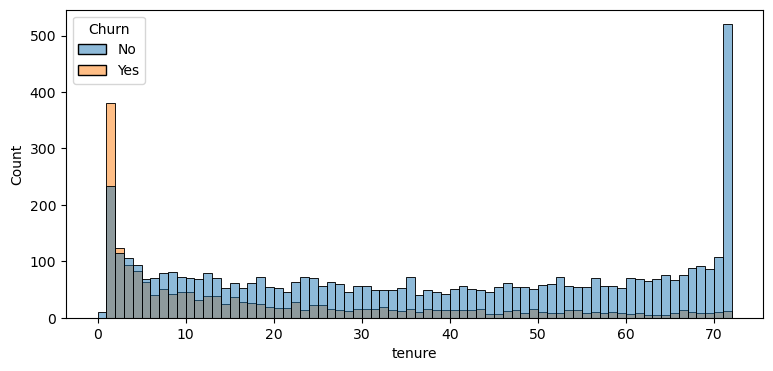

In [27]:
plt.figure(figsize = (9,4))
sns.histplot(x = 'tenure', data = df, bins = 72, hue = 'Churn')
plt.show()

#People who have used our services for long time have stayed and people who have used our services #1 or 2 months have churned 

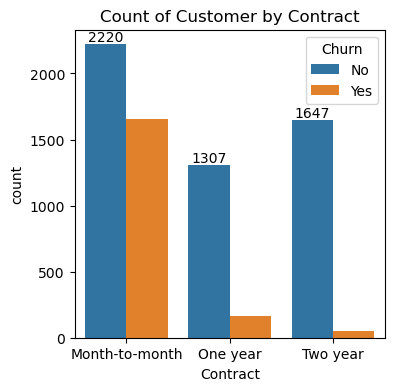

In [30]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x ='Contract', data = df, hue = 'Churn')
ax.bar_label(ax.containers[0])
plt.title('Count of Customer by Contract')
plt.show()

#people who have month to month contract are likely to are churn then from those who have 1 or 2 years of contract

In [33]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

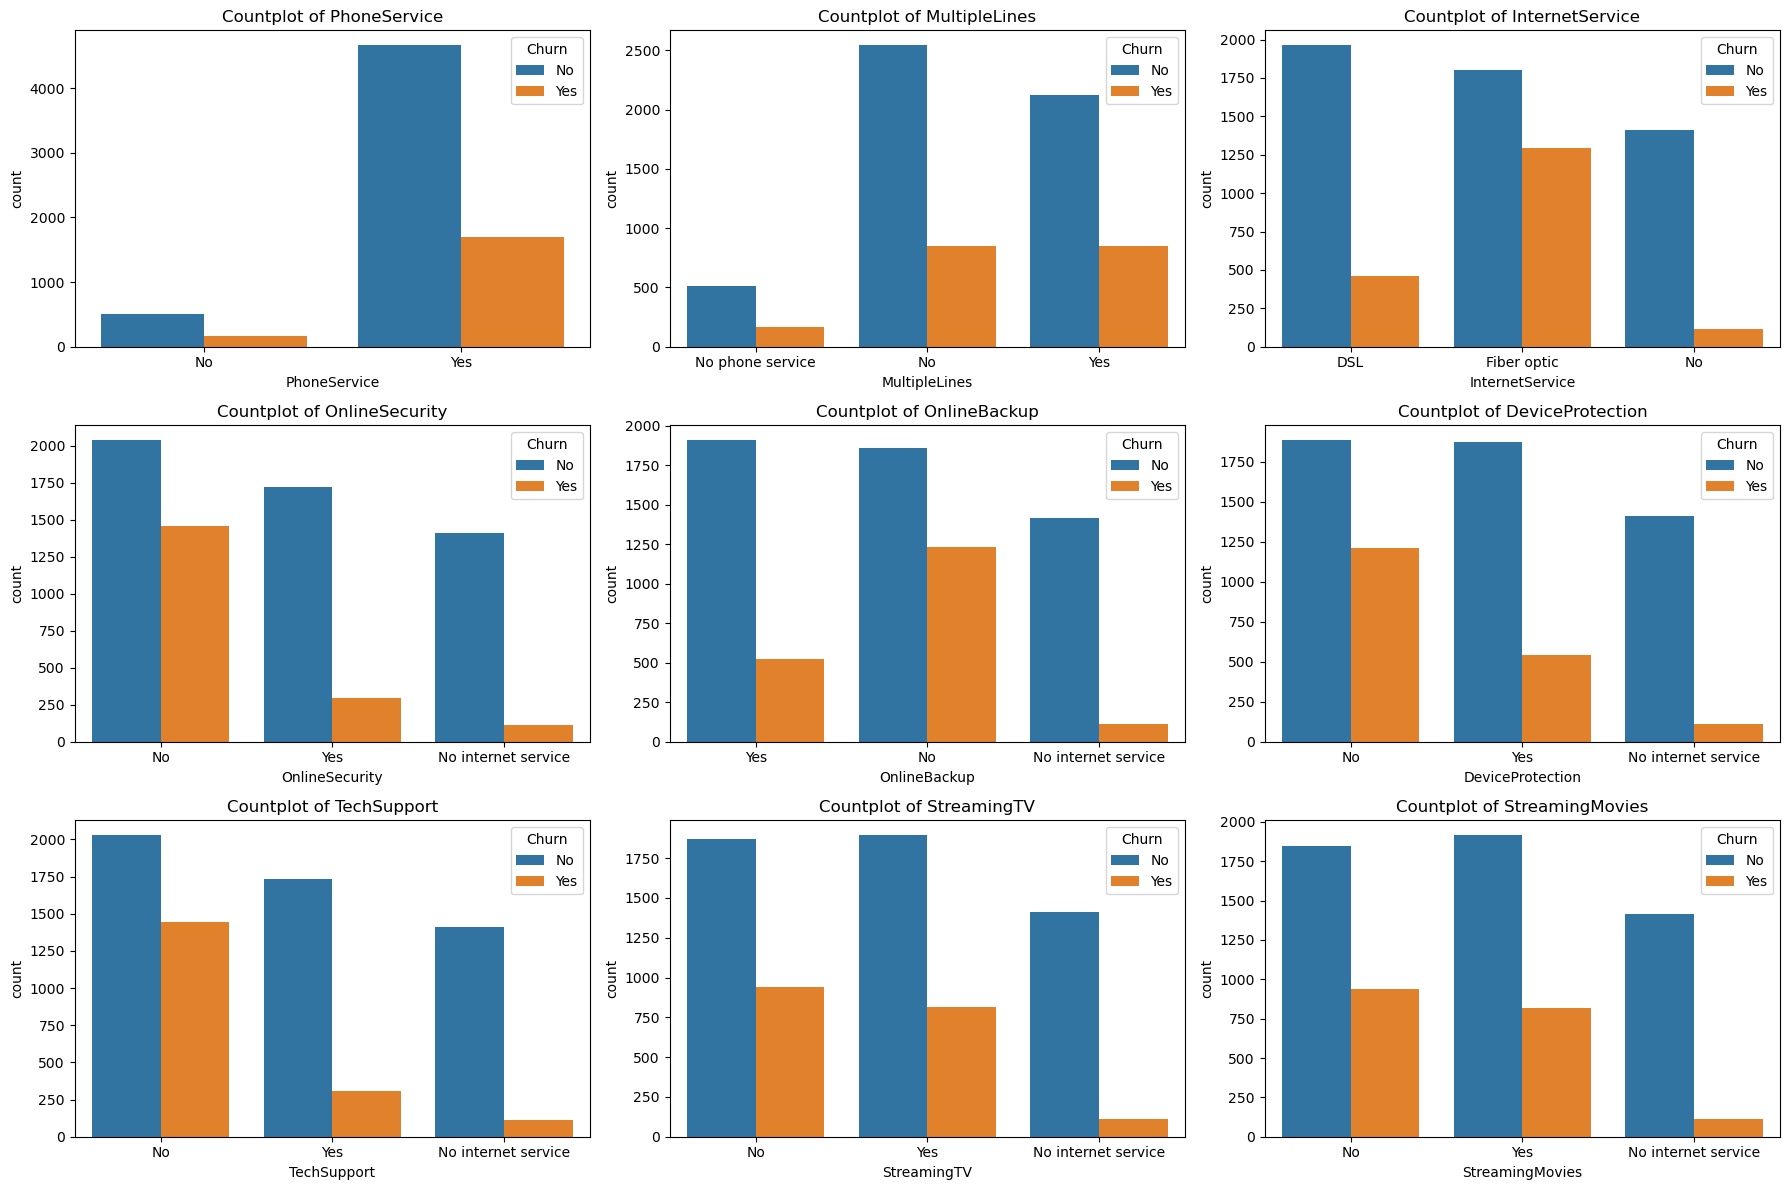

In [35]:
# List of columns to plot
cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

# Set up the subplot grid
n_cols = 3  # Number of columns in subplot grid
n_rows = (len(cols) + n_cols - 1) // n_cols  # Calculate rows needed
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axes = axes.flatten()  # Flatten to make indexing easier

# Plot countplots for each column
for i, col in enumerate(cols):
    sns.countplot(data=df, x=col, ax=axes[i], hue = df ['Churn'])
    axes[i].set_title(f'Countplot of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('count')

# Remove any unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#This chart shows how different services affect customer churn. People without online security, backup, or tech support are more likely to leave. Fiber optic internet users also churn more than DSL or no-internet users. Having streaming services or multiple lines doesn't strongly reduce churn. Overall, lack of protection and support services seems linked to higher churn.

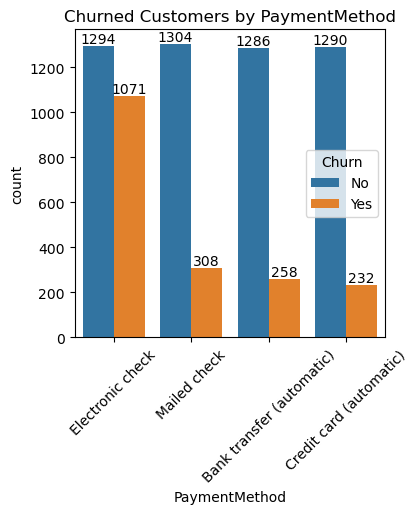

In [40]:
plt.figure(figsize = (4,4))
ax = sns.countplot(x ='PaymentMethod', data = df, hue = 'Churn')
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title('Churned Customers by PaymentMethod')
plt.xticks(rotation = 45)
plt.show()

#customer likely o churn when he is using electronic check as a payment method. 